In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
import numba as nb

def laplacian_periodic_1d(h):
    # h: shape (n,)
    # 拡張してからスライス
    ext = np.empty(h.size + 2, dtype=h.dtype)
    ext[1:-1] = h
    ext[0]    = h[-1]
    ext[-1]   = h[0]
    return ext[:-2] - 2.0*h + ext[2:]

def EW(dh = 0.1, eta = 0.1, ks = 0.1, dt=0.1, dx = 1, L=100, T=2000):

    n=int(L/dx);
    loop = int(T/dt)

    h = np.zeros(n)
    dhdxdx = dh/dx/dx
    eta_sqrt_dt = eta * np.sqrt(dt)

    for t in range(loop):
        h += (dt*(
            dhdxdx*(laplacian_periodic_1d(h))
            - ks * h
            )
            + eta_sqrt_dt * np.random.randn(n)
        )
    return h




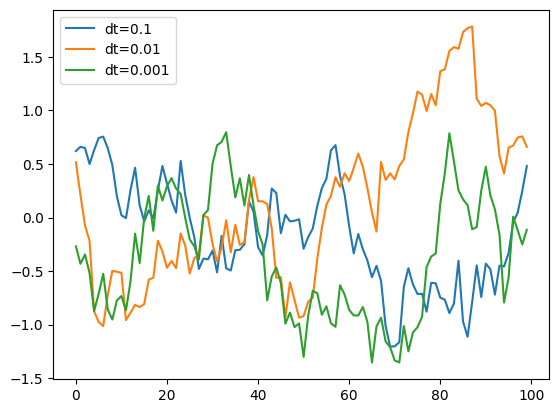

In [77]:
plt.plot(EW(dt=0.1), label='dt=0.1')
plt.plot(EW(dt=0.01), label='dt=0.01')
plt.plot(EW(dt=0.001), label='dt=0.001')
plt.legend()

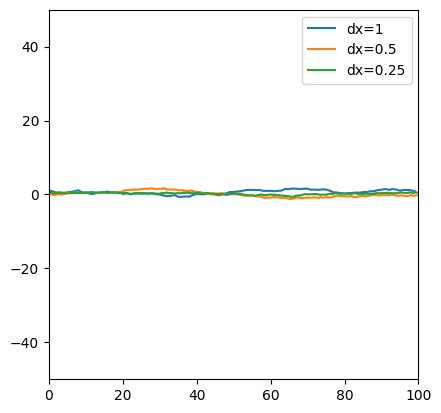

In [78]:
# 各データを取得
data1 = EW(dx=1)
data2 = EW(dx=0.5)
data3 = EW(dx=0.25)

# 物理的なx軸を作成（インデックス * dx）
x1 = np.arange(len(data1)) * 1
x2 = np.arange(len(data2)) * 0.5
x3 = np.arange(len(data3)) * 0.25

# 全てのプロットを描画
plt.plot(x1, data1, label='dx=1')
plt.plot(x2, data2, label='dx=0.5')
plt.plot(x3, data3, label='dx=0.25')

# 物理的な長さの最大値を計算してxlimを設定
max_physical_length = max(len(data1) * 1, len(data2) * 0.5, len(data3) * 0.25)
plt.xlim(0, max_physical_length)

plt.legend()
plt.ylim(-50, 50)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()


0.01
0.015
0.019999999999999997
0.024999999999999998
0.03
0.034999999999999996
0.039999999999999994
0.045
0.049999999999999996
0.05499999999999999
0.05999999999999999
0.06499999999999999
0.06999999999999999
0.07499999999999998
0.07999999999999999
0.08499999999999999
0.08999999999999998
0.09499999999999999
0.09999999999999999
0.10499999999999998
0.10999999999999999
0.11499999999999999
0.11999999999999998
0.12499999999999999
0.12999999999999998
0.13499999999999998
0.13999999999999999
0.145
0.14999999999999997
0.15499999999999997
0.15999999999999998
0.16499999999999998
0.16999999999999998
0.175
0.17999999999999997
0.18499999999999997
0.18999999999999997
0.19499999999999998


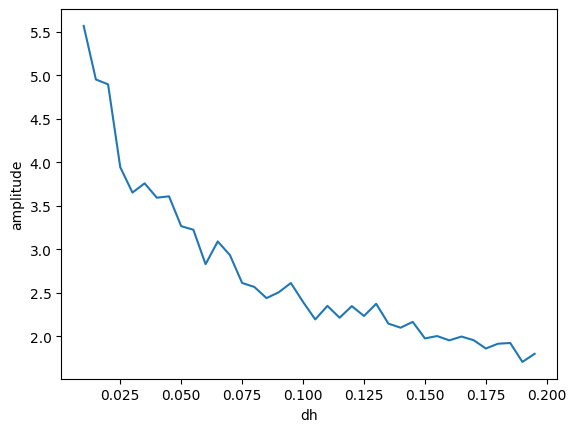

In [79]:
def amplitude(h):
    return np.max(h)-np.min(h)

dhList = np.arange(0.01, 0.2, 0.005)
ampMeanList = []
for dh in dhList:
    print(dh)
    ampList = []
    for i in range(20):
        ampList.append(amplitude(EW(dh=dh, T=2000)))
    ampMeanList.append(np.mean(ampList))

plt.plot(dhList, ampMeanList)
plt.ylabel('amplitude')
plt.xlabel('dh')
plt.show()



<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z3/qtwkwxv15gq8vr6m4nbgff_w0000gq/T/ipykernel_22043/2312339271.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sqrt{dh}$')


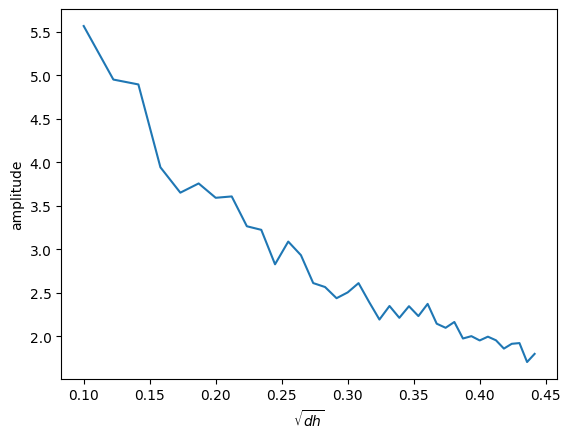

In [80]:
plt.plot(np.sqrt(dhList), ampMeanList)
plt.ylabel('amplitude')
plt.xlabel('$\sqrt{dh}$')
plt.show()

In [90]:
ksList = np.arange(0.2,4,0.2)
ampMeanList = []
for ks in ksList:
    print(ks)
    ampList = []
    for i in range(20):
        ampList.append(amplitude(EW(ks=ks, T=2000)))
    ampMeanList.append(np.mean(ampList))


0.2
0.4
0.6000000000000001
0.8
1.0
1.2000000000000002
1.4000000000000001
1.6
1.8
2.0
2.2
2.4000000000000004
2.6
2.8000000000000003
3.0
3.2
3.4000000000000004
3.6
3.8000000000000003


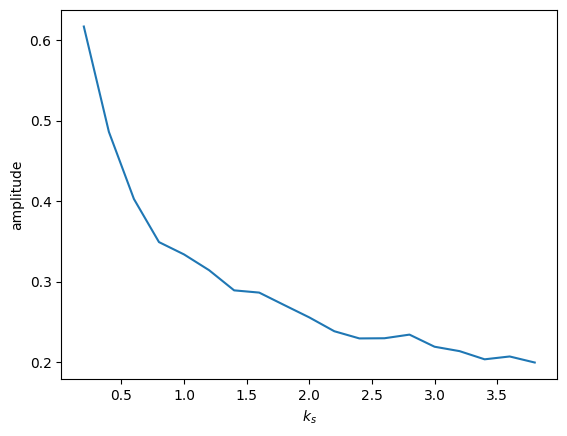

In [91]:
plt.plot(ksList, ampMeanList)
plt.ylabel('amplitude')
plt.xlabel('$k_s$')
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/z3/qtwkwxv15gq8vr6m4nbgff_w0000gq/T/ipykernel_22043/2446551859.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sqrt{k_s}$')


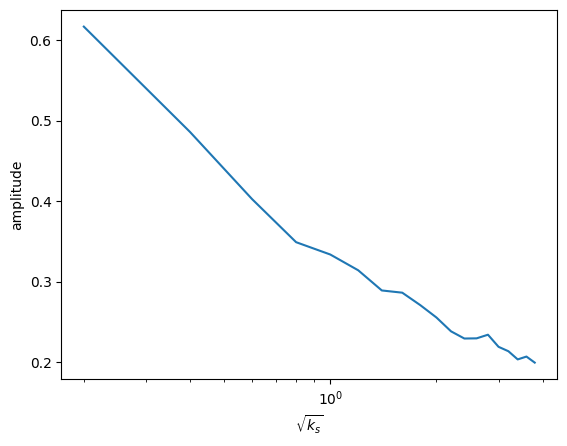

In [ ]:
plt.plot(ksList, ampMeanList)
plt.xscale('log')
plt.ylabel('amplitude')
plt.xlabel('$k_s$')
plt.show()

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


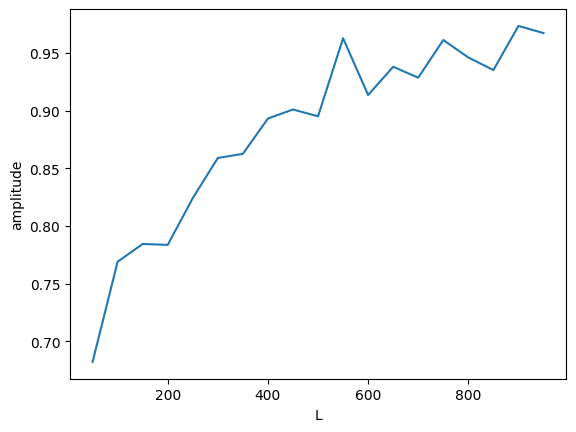

In [96]:
LList = np.arange(50, 1000, 50)
ampMeanList = []
for L in LList:
    print(L)
    ampList = []
    for i in range(20):
        ampList.append(amplitude(EW(L=L, T=2000)))
    ampMeanList.append(np.mean(ampList))

plt.plot(LList, ampMeanList)
plt.ylabel('amplitude')
plt.xlabel('L')
plt.show()

In [ ]:
TList = np.arange(100, 3000, 100)
ampMeanList = []
for T in TList:
    print(T)
    ampList = []
    for i in range(20):
        ampList.append(amplitude(EW(T=T)))
    ampMeanList.append(np.mean(ampList))



100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900


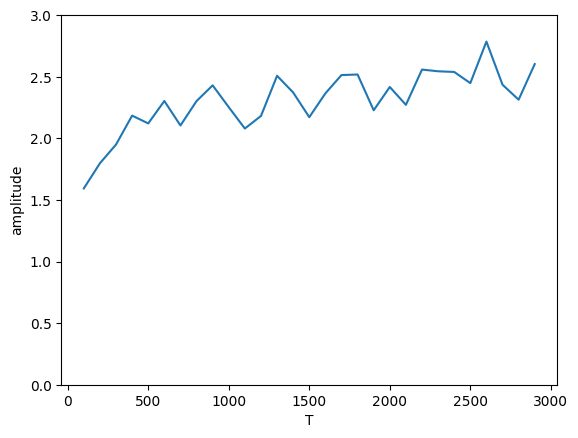

In [ ]:
plt.plot(TList, ampMeanList)
plt.ylabel('amplitude')
plt.xlabel('T')
plt.ylim(0, 3)
plt.show()